In [5]:
# Use local version of systemdynamics instead of installed package
import sys
import os

# Get the parent directory (where systemdynamics package is located)
local_package_path = os.path.abspath(os.path.join(os.getcwd(), '..'))
if local_package_path not in sys.path:
    sys.path.insert(0, local_package_path)

# Remove any installed systemdynamics from path to avoid conflicts
sys.modules.pop('systemdynamics', None)
sys.modules.pop('systemdynamics.sdm', None)
sys.modules.pop('systemdynamics.cld', None)

## D2D Example: CLD on Alzheimer's Disease
In this example, we  implement a diagrams-to-dynamics (D2D) analysis of a causal loop diagram (CLD) published by Uleman et al (2020) doi: 10.1007/s11357-020-00228-7. This CLD was turned into a data-driven system dynamics model (SDM) in Uleman (2023) doi: 10.1002/alz.12923. 

In Kumu, the SDM looks as follows:

<img src="Alzheimer CLD.jpg" alt="drawing" width="500"/>

To analyze this CLD, we will first imports the settings and the Kumu file. We will then run the simulations with what-if scenarios, assess the intervention effects, and then perform sensitivity analysis over the model parameters.

In [6]:
import os
from systemdynamics.cld import Extract
from systemdynamics.sdm import SDM
from systemdynamics.plots import plot_simulated_intervention_ranking

current_path = os.getcwd()  # Select current path
file_name = "Alzheimer"  # Specify the relevant name of the CLD Excel file
file_path = os.path.join(current_path, f"{file_name}.xlsx")

extract = Extract(file_path)  # Load the relevant Kumu file extraction module
s = extract.extract_settings()  # Extract the settings using the Kumu Excel file

# Set simulation settings
s.seed = 1912884
s.N = 100  # Number of simulations
s.t_end = 20  # Timeframe of the simulation
s.time_unit = "quarter-years"  # Base unit of time (time unit of t_end)
s.parameter_value_aux = 0.1
s.parameter_value_stocks = 0.1

# Load the module for formulating and simulating the SDM
sdm = SDM(s)  


Variable of interest: Cognitive functioning
with 3 intervention variables
Removed 2.0 incoming links for constant Diabetes
Removed 4.0 incoming links for constant Dyslipidaemia
Removed 6.0 incoming links for constant Social relationships
Removed 1.0 incoming links for constant Hearing loss
Removed 2.0 incoming links for constant Smoking
Removed 1.0 incoming links for constant Excessive alcohol use
Removed 4.0 incoming links for constant Motor function

75 feedback loops of maximum length 5
All loops have at least one stock
No interaction terms specified so will solve linear SDM.


In [7]:
df_sol, param_samples = sdm.run_simulations()  # Run the simulated interventions
intervention_effects_per_voi = sdm.get_intervention_effects()  # Get the intervention effects

Running Simulations:   2%|▏         | 2/100 [00:00<00:05, 18.98it/s]

Running Simulations: 100%|██████████| 100/100 [00:05<00:00, 17.64it/s]


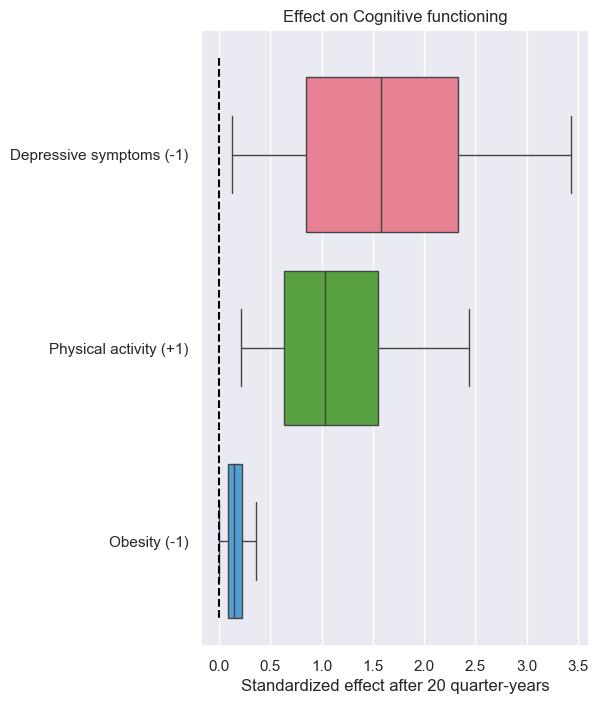

In [8]:
for voi in s.variable_of_interest:
    plot_simulated_intervention_ranking(s, intervention_effects_per_voi[voi], 
                                        voi, top_plot=None, order=None);  # Plot the simulated interventions ranking

Given these settings, we can now run simulations from the SDM-converted CLD.

In [9]:
for voi in s.variable_of_interest:
    print("---- Variable of Interest: ", voi)
    sdm.compare_interventions_table(intervention_effects_per_voi[voi])  # Print the table of the simulated interventions
    print("")

---- Variable of Interest:  Cognitive functioning

Comparison Table (Percentage Greater, 95% CI, Cliff’s Delta):
+---------------------+-------------------+-------------+----------------------+-----------------+
| Intervention A      | Intervention B    |   % Greater | 95% CI (% Greater)   |   Cliff's Delta |
+=====================+===================+=============+======================+=================+
| Depressive symptoms | Physical activity |          76 | [67.0, 84.0]         |            0.52 |
+---------------------+-------------------+-------------+----------------------+-----------------+
| Depressive symptoms | Obesity           |          98 | [95.0, 100.0]        |            0.96 |
+---------------------+-------------------+-------------+----------------------+-----------------+
| Physical activity   | Obesity           |         100 | [100.0, 100.0]       |            1    |
+---------------------+-------------------+-------------+----------------------+---------------

## Sensitivity analysis

In [10]:
## Estimate spearman correlation for the model parameters, either for one intervention variable (int_var) or for all
cut_off_SA_importance = 0.08
int_var = None # If None, the simulations of all intervention will be used

for voi in s.variable_of_interest:
    print("---- Variable of Interest: ", voi)
    outcome_var = voi  # If None, all variables will be used to assess change in the model
    SA_results, df_SA = sdm.run_SA(outcome_var, int_var, cut_off_SA_importance)
    print("")


---- Variable of Interest:  Cognitive functioning
+-----------------------------------------------------------------+-------+--------------------+------------------+----------------+
|                              Link                               |  Rho  | 95% CI (bootstrap) | Mean Rho per Int | SD Rho per Int |
+-----------------------------------------------------------------+-------+--------------------+------------------+----------------+
|           Depressive symptoms->Cognitive functioning            | -0.4  |    [-0.5, -0.3]    |      -0.61       |      0.32      |
|             Physical activity->Depressive symptoms              | -0.19 |   [-0.3, -0.08]    |      -0.34       |      0.22      |
|              Sleep quality->Cognitive functioning               | 0.16  |    [0.06, 0.28]    |       0.25       |      0.05      |
|                   Obesity->Physical activity                    | -0.16 |   [-0.27, -0.05]   |       -0.3       |      0.08      |
|              Expe

## Optimization of incentives with constaint

In [12]:
# Simple optimization across parameter samples
from tqdm import tqdm

# Configure costs per intervention and whether to maximize or minimize the VOI
# Make Depressive symptoms an order of magnitude more expensive than the others
costs = [10.0] + [1.0] * (len(s.intervention_variables) - 1)
maximize_voi = True  # set False to minimize
voi_name = s.variable_of_interest[0]

# Run global optimization across all sampled parameter sets
opt_df = sdm.optimize_across_parameter_samples(
    costs=costs,
    variable_of_interest=voi_name,
    method='global',
    maximize=maximize_voi
)

# Summarize distribution of optimal intensities
intensity_cols = [c for c in opt_df.columns if c.startswith('intensity_')]
display(opt_df[intensity_cols].describe())
print("First few rows of optimization results:")
display(opt_df.head())

Optimizing across parameter samples (global): 100%|██████████| 100/100 [01:47<00:00,  1.08s/it]


,intensity_Depressive symptoms,intensity_Obesity,intensity_Physical activity
count,307.0,307.0,307.0
mean,0.0,0.0,1.0
std,0.0,0.0,0.0
min,0.0,0.0,1.0
25%,0.0,0.0,1.0
50%,0.0,0.0,1.0
75%,0.0,0.0,1.0
max,0.0,0.0,1.0


First few rows of optimization results:


,sample_idx,equilibrium_idx,intensity_Depressive symptoms,intensity_Obesity,intensity_Physical activity,voi_effect_size,total_cost,n_equilibria
0,0,0,0.0,0.0,1.0,1.949036,1.0,2
1,0,1,0.0,0.0,1.0,1.949036,1.0,2
2,1,0,0.0,0.0,1.0,0.409426,1.0,3
3,1,1,0.0,0.0,1.0,0.409426,1.0,3
4,1,2,0.0,0.0,1.0,0.409426,1.0,3


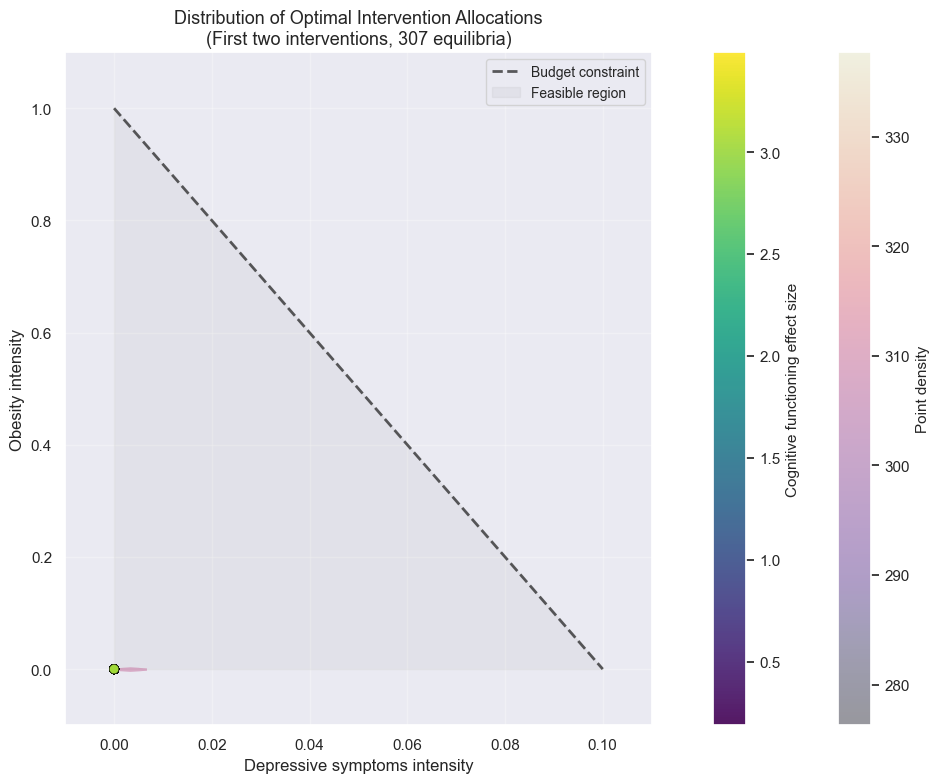

Optimization results summary (307 equilibria):
  Depressive symptoms: mean=0.000, std=0.000, range=[0.000, 0.000]
  Obesity: mean=0.000, std=0.000, range=[0.000, 0.000]
  Physical activity: mean=1.000, std=0.000, range=[1.000, 1.000]


In [15]:
# Plot distribution of optimal intensities in 2D simplex (first two interventions)
import matplotlib.pyplot as plt
import numpy as np

# Get the first two intervention variables
int_var_1 = s.intervention_variables[0]
int_var_2 = s.intervention_variables[1]
int_var_3 = s.intervention_variables[2] if len(s.intervention_variables) > 2 else None

# Extract intensities from optimization results
x = opt_df[f'intensity_{int_var_1}'].values
y = opt_df[f'intensity_{int_var_2}'].values
effects = opt_df['voi_effect_size'].values

# Create figure
fig, ax = plt.subplots(figsize=(10, 8))

# Plot the feasible region boundary (budget constraint: x + y <= 1.0 for equal costs)
if len(costs) >= 2:
    # Budget constraint: intensity_1 * cost_1 + intensity_2 * cost_2 <= 1.0
    max_x = 1.0 / costs[0]
    max_y = 1.0 / costs[1]
    
    # Plot constraint boundary
    x_boundary = np.linspace(0, max_x, 100)
    y_boundary = (1.0 - x_boundary * costs[0]) / costs[1]
    y_boundary = np.maximum(y_boundary, 0)  # Clip negative values
    ax.plot(x_boundary, y_boundary, 'k--', linewidth=2, label='Budget constraint', alpha=0.7, zorder=2)
    
    # Fill feasible region
    ax.fill_between(x_boundary, 0, y_boundary, alpha=0.08, color='gray', label='Feasible region', zorder=1)

# Density layer: hexbin counts to show clustering (keep behind points)
hb = ax.hexbin(x, y, gridsize=30, cmap='magma', mincnt=1, linewidths=0.1, alpha=0.35, zorder=1)
cbar_density = plt.colorbar(hb, ax=ax, pad=0.012)
cbar_density.set_label('Point density', fontsize=11)

# Scatter plot colored by effect size; bring to front
scatter = ax.scatter(
    x,
    y,
    c=effects,
    cmap='viridis',
    s=46,
    alpha=0.9,
    edgecolors='black',
    linewidth=0.35,
    zorder=3,
)
cbar_effect = plt.colorbar(scatter, ax=ax, pad=0.08)
cbar_effect.set_label(f'{voi_name} effect size', fontsize=11)

ax.set_xlabel(f'{int_var_1} intensity', fontsize=12)
ax.set_ylabel(f'{int_var_2} intensity', fontsize=12)
ax.set_title(f'Distribution of Optimal Intervention Allocations\n(First two interventions, {len(opt_df)} equilibria)', fontsize=13)
ax.legend(loc='upper right', fontsize=10)
ax.grid(True, alpha=0.3)

# Set axis limits with padding proportional to max_x and max_y for consistent appearance across different costs
if len(costs) >= 2:
    margin_x = (1.0 / costs[0]) * 0.1
    margin_y = (1.0 / costs[1]) * 0.1
    ax.set_xlim(left=-margin_x, right=1.0 / costs[0] + margin_x)
    ax.set_ylim(bottom=-margin_y, top=1.0 / costs[1] + margin_y)

plt.tight_layout()
plt.show()

# Print summary statistics
print(f"Optimization results summary ({len(opt_df)} equilibria):")
print(f"  {int_var_1}: mean={x.mean():.3f}, std={x.std():.3f}, range=[{x.min():.3f}, {x.max():.3f}]")
print(f"  {int_var_2}: mean={y.mean():.3f}, std={y.std():.3f}, range=[{y.min():.3f}, {y.max():.3f}]")
if int_var_3:
    z = opt_df[f'intensity_{int_var_3}'].values
    print(f"  {int_var_3}: mean={z.mean():.3f}, std={z.std():.3f}, range=[{z.min():.3f}, {z.max():.3f}]")

## Loops That Matter (LTM) Analysis
The Loops That Matter method quantitatively identifies which feedback loops are most responsible for the model's behavior at each time point. It computes:
1. **Link scores**: contribution of each causal link to variable changes
2. **Loop scores**: product of link scores around feedback loops
3. **Relative loop scores**: normalized measure of loop dominance (-1 to 1)

In [16]:
# Initialize LTM analysis
from systemdynamics.ltm import LoopsThatMatter

ltm = LoopsThatMatter(sdm)
ltm.print_loops()  # Show identified feedback loops


Identified 3158 feedback loops:

  R1 (Reinforcing): Cognitive functioning → Depressive symptoms → Cognitive functioning
  R2 (Reinforcing): Cognitive functioning → Depressive symptoms → Healthy dietary patterns → Neuronal dysfunction → Cognitive functioning
  R3 (Reinforcing): Cognitive functioning → Depressive symptoms → Healthy dietary patterns → Neuronal dysfunction → Brain atrophy → Cognitive functioning
  R4 (Reinforcing): Cognitive functioning → Depressive symptoms → Healthy dietary patterns → Neuronal dysfunction → Systemic inflammation → Cerebral endothelial dysfunction → Brain perfusion → Cognitive functioning
  R5 (Reinforcing): Cognitive functioning → Depressive symptoms → Healthy dietary patterns → Neuronal dysfunction → Systemic inflammation → Neuroinflammation → Amyloid beta burden → Cerebral endothelial dysfunction → Brain perfusion → Cognitive functioning
  R6 (Reinforcing): Cognitive functioning → Depressive symptoms → Healthy dietary patterns → Neuronal dysfunction 

In [ ]:
# Run LTM analysis using optimal intervention intensities from the optimization
# Get the best intervention allocation from opt_df (highest effect size)
best_idx = opt_df['voi_effect_size'].idxmax()
best_row = opt_df.loc[best_idx]

# Extract optimal intensities
optimal_intensities = [best_row[f'intensity_{var}'] for var in s.intervention_variables]
print(f"Using optimal intervention intensities (effect size = {best_row['voi_effect_size']:.4f}):")
for var, intensity in zip(s.intervention_variables, optimal_intensities):
    if intensity > 0.01:
        print(f"  {var}: {intensity:.4f}")

# Run LTM analysis with these interventions
params = sdm.sample_model_parameters()
df_sol_ltm, link_scores_df, loop_scores_df = ltm.run_ltm_analysis(
    params, 
    t_start=0, 
    t_end=s.t_end, 
    n_points=50,
    intervention_intensities=optimal_intensities
)

# Display loop scores over time
print("\nLoop scores over time (first 10 rows):")
display(loop_scores_df.head(10))

# Get loop summary
loop_summary = ltm.get_loop_summary()
print("\nLoop summary:")
display(loop_summary)

Loop scores over time:


,time,R1_relative,R1_raw,R2_relative,R2_raw,R3_relative,R3_raw,R4_relative,R4_raw,R5_relative,...,R3154_relative,R3154_raw,R3155_relative,R3155_raw,R3156_relative,R3156_raw,R3157_relative,R3157_raw,R3158_relative,R3158_raw
0,0.408163,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.816327,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1.224490,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1.632653,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2.040816,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,2.448980,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,2.857143,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,3.265306,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,3.673469,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,4.081633,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


,loop_name,loop_type,loop_variables,mean_score,max_abs_score,std_score,time_dominant
0,R1,Reinforcing,Cognitive functioning → Depressive symptoms,0.0,0.0,0.0,1.0
1,R2,Reinforcing,Cognitive functioning → Depressive symptoms → ...,0.0,0.0,0.0,1.0
2,R3,Reinforcing,Cognitive functioning → Depressive symptoms → ...,0.0,0.0,0.0,1.0
3,R4,Reinforcing,Cognitive functioning → Depressive symptoms → ...,0.0,0.0,0.0,1.0
4,R5,Reinforcing,Cognitive functioning → Depressive symptoms → ...,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...
3153,R3154,Reinforcing,Neuronal dysfunction → Oxidative stress → Neur...,0.0,0.0,0.0,1.0
3154,R3155,Reinforcing,Systemic inflammation → Morbidity burden,0.0,0.0,0.0,1.0
3155,R3156,Reinforcing,Neuroinflammation → Amyloid beta burden,0.0,0.0,0.0,1.0
3156,R3157,Reinforcing,Brain perfusion → Cerebral endothelial dysfunc...,0.0,0.0,0.0,1.0


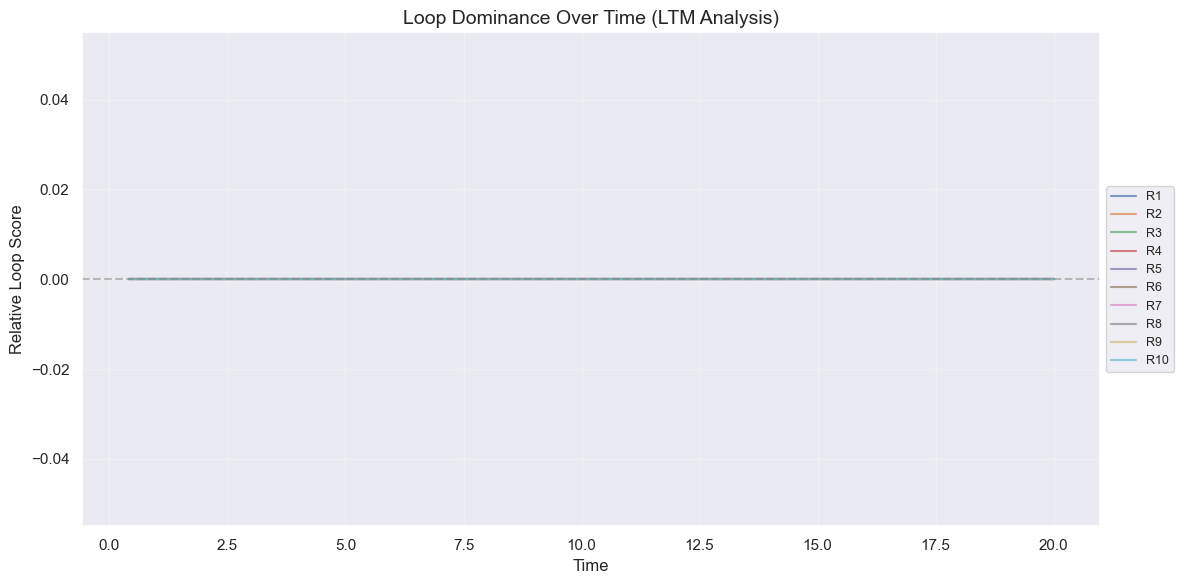


Dominant loops at key time points:
  t=0.0: None (score=0.000)
  t=5.0: None (score=0.000)
  t=10.0: None (score=0.000)
  t=15.0: None (score=0.000)
  t=20.0: None (score=0.000)


In [ ]:
# Plot loop dominance over time with optimal intervention
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 6))

# Plot relative scores for each loop (limit to loops with non-zero scores)
active_loops = []
for loop_name in ltm.loop_names:
    col = f'{loop_name}_relative'
    if col in loop_scores_df.columns:
        max_score = loop_scores_df[col].abs().max()
        if max_score > 0.01:  # Only plot loops with meaningful scores
            active_loops.append(loop_name)
            color = 'red' if loop_name.startswith('R') else 'blue'
            ax.plot(loop_scores_df['time'], loop_scores_df[col], 
                    label=loop_name, alpha=0.7, linewidth=1.5)

ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('Time', fontsize=12)
ax.set_ylabel('Relative Loop Score', fontsize=12)
ax.set_title(f'Loop Dominance Over Time with Optimal Intervention\n({len(active_loops)} active loops shown)', fontsize=14)
if len(active_loops) <= 15:
    ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Show which loop is dominant at key time points
print("\nDominant loops at key time points:")
for t in [0.1, s.t_end/4, s.t_end/2, 3*s.t_end/4, s.t_end]:
    dom_loop, score = ltm.get_dominant_loop_at_time(t)
    if dom_loop:
        print(f"  t={t:.1f}: {dom_loop} (score={score:.3f})")

In [ ]:
# Run LTM across multiple parameter samples WITH the optimal intervention
# This shows how loop dominance varies across parameter uncertainty
ltm_results_df = ltm.run_ltm_across_samples(
    n_samples=min(20, s.N), 
    n_points=30,
    intervention_intensities=optimal_intensities
)

# Aggregate loop scores across samples
print("Aggregated loop dominance across parameter samples:")
loop_cols = [col for col in ltm_results_df.columns if '_relative' in col]
agg_stats = ltm_results_df.groupby('time')[loop_cols].agg(['mean', 'std'])
display(agg_stats.head())

## Additional figures

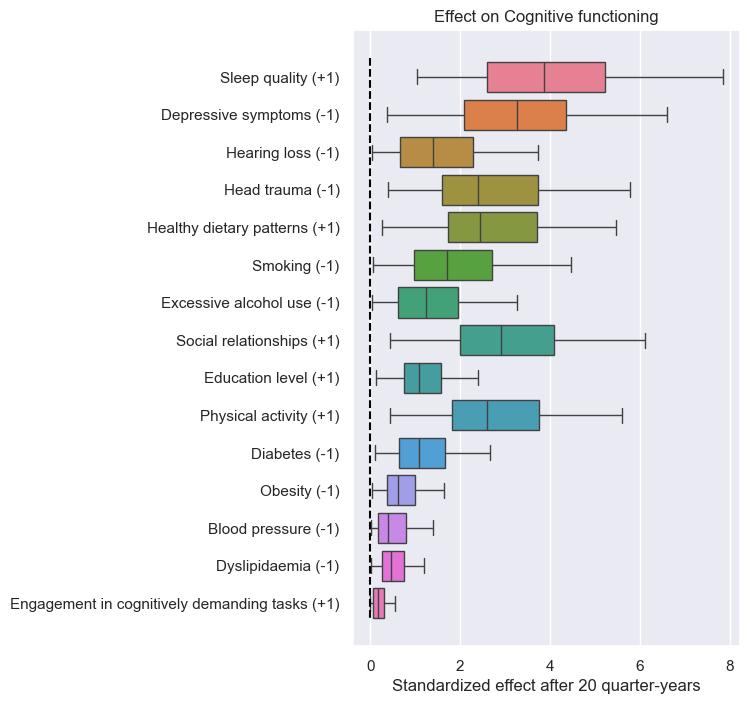

In [7]:
datadriven_ranking = ["Sleep quality", "Depressive symptoms", "Hearing loss", "Head trauma", 
                      "Healthy dietary patterns", "Smoking", "Excessive alcohol use", 
                      "Social relationships", "Education level", "Physical activity", 
                      "Diabetes", "Obesity", "Blood pressure", "Dyslipidaemia", 
                      "Engagement in cognitively demanding tasks"]

plot_simulated_intervention_ranking(s, intervention_effects_per_voi[voi], voi,
                                    top_plot=None, order=datadriven_ranking);

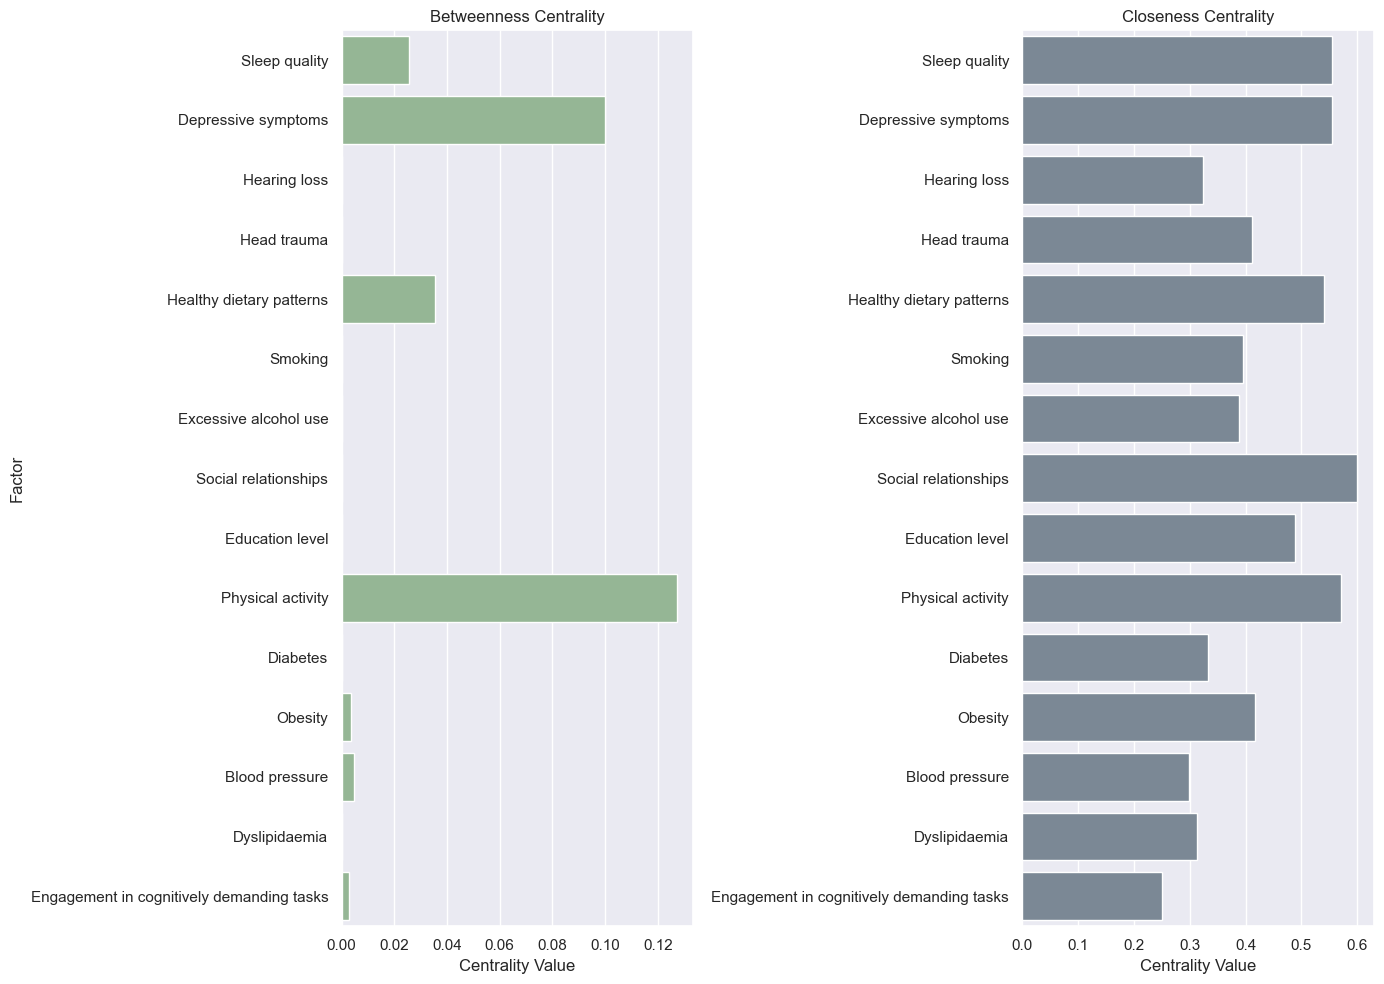

In [9]:
## Centrality plot for comparison
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

def plot_centrality(s, datadriven_ranking):
    """ Plot the betweenness and closeness centrality rankings of the system for comparison purposes.
    """
    datadriven_ranking = [" ".join(x.split('_')) for x in datadriven_ranking]

    # Create a DataFrame
    centrality_df = pd.DataFrame(s.centrality)
    centrality_df["Factor"] = centrality_df.index

    # Filter for the selected 15 factors
    centrality_df = centrality_df[centrality_df["Factor"].isin([var.replace('_', ' ') for var in s.intervention_variables])]

    # Sort DataFrames by centrality values
    df_betweenness = centrality_df.sort_values(by="betweenness", ascending=False)
    df_closeness = centrality_df.sort_values(by="closeness", ascending=False)

    # Plot
    fig, axes = plt.subplots(1, 2, figsize=(14, 10), sharex=False)
    #fig, axes = plt.subplots(1, 1, figsize=(7, 10), sharex=True)
    sns.barplot(data=df_betweenness.loc[datadriven_ranking, :], y="Factor", x="betweenness", ax=axes[0], color='darkseagreen')
    axes[0].set_title("Betweenness Centrality")
    axes[0].set_xlabel("Centrality Value")
    axes[0].set_ylabel("Factor")

    sns.barplot(data=df_closeness.loc[datadriven_ranking, :], y="Factor", x="closeness", ax=axes[1], color='lightslategray')
    axes[1].set_title("Closeness Centrality")
    axes[1].set_xlabel("Centrality Value")
    axes[1].set_ylabel("")  # Remove y-axis label to avoid redundancy

    plt.tight_layout()
    plt.show()

plot_centrality(s, datadriven_ranking)

In [66]:
df_intervention_effects = pd.DataFrame(intervention_effects_per_voi[voi], columns=s.intervention_variables)

# Add centrality and data-driven rankings
df_intervention_effects.loc['Closeness'] = [s.centrality['closeness'].get(var, 0) for var in df_intervention_effects.columns]
df_intervention_effects.loc['Betweenness'] = [s.centrality['betweenness'].get(var, 0) for var in df_intervention_effects.columns]
df_intervention_effects.loc['Data-driven'] = [len(datadriven_ranking) - datadriven_ranking.index(var) if var in datadriven_ranking else 0 for var in df_intervention_effects.columns]

# Calculate correlations
median_values = df_intervention_effects.loc[0:199].median()
datadriven_values = df_intervention_effects.loc["Data-driven"]
closeness_values = df_intervention_effects.loc["Closeness"]
betweenness_values = df_intervention_effects.loc["Betweenness"]

print(f"Correlation Data-driven SDM and D2D: {median_values.corr(datadriven_values, method='spearman'):.2f}")
print(f"Correlation Data-driven SDM and Closeness: {datadriven_values.corr(closeness_values, method='spearman'):.2f}")
print(f"Correlation Data-driven SDM and Betweenness: {datadriven_values.corr(betweenness_values, method='spearman'):.2f}")


Correlation Data-driven SDM and D2D: 0.82
Correlation Data-driven SDM and Closeness: 0.51
Correlation Data-driven SDM and Betweenness: 0.11
